# 02 — Data Exploration & Coverage Report

**Goal**: Understand each data source's shape, coverage, missing rates, and cross-source overlap.  
**Output**: Summary tables + figures for the midterm presentation (7/1).  
**Dependency**: `src/data_loader.py` (Yannan's PR #1, `yannan` branch)

## 0. Setup

In [1]:
import sys, os
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 如果没装 matplotlib-venn，先运行: pip install matplotlib-venn
from matplotlib_venn import venn2, venn3

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# 创建报告图片输出文件夹
os.makedirs('../report/figures', exist_ok=True)

print('Setup done.')

Setup done.


In [2]:
from data_loader import CellLineDataLoader

loader = CellLineDataLoader('../data')
print('CellLineDataLoader initialised. Data dir:', loader.data_dir)

CellLineDataLoader initialised. Data dir: ..\data


## 1. Master Cell Line Table (File 9: sample_info)

In [3]:
si = loader.sample_info
print(f'Shape: {si.shape}')
print(f'Columns: {list(si.columns)}')
si.head(3)

Shape: (1840, 29)
Columns: ['DepMap_ID', 'cell_line_name', 'stripped_cell_line_name', 'CCLE_Name', 'alias', 'COSMICID', 'sex', 'source', 'RRID', 'WTSI_Master_Cell_ID', 'sample_collection_site', 'primary_or_metastasis', 'primary_disease', 'Subtype', 'age', 'Sanger_Model_ID', 'depmap_public_comments', 'lineage', 'lineage_subtype', 'lineage_sub_subtype', 'lineage_molecular_subtype', 'default_growth_pattern', 'model_manipulation', 'model_manipulation_details', 'patient_id', 'parent_depmap_id', 'Cellosaurus_NCIt_disease', 'Cellosaurus_NCIt_id', 'Cellosaurus_issues']


,DepMap_ID,cell_line_name,stripped_cell_line_name,CCLE_Name,alias,COSMICID,sex,source,RRID,WTSI_Master_Cell_ID,...,lineage_sub_subtype,lineage_molecular_subtype,default_growth_pattern,model_manipulation,model_manipulation_details,patient_id,parent_depmap_id,Cellosaurus_NCIt_disease,Cellosaurus_NCIt_id,Cellosaurus_issues
0,ACH-000016,SLR 21,SLR21,SLR21_KIDNEY,NaN,NaN,NaN,Academic lab,CVCL_V607,NaN,...,NaN,NaN,NaN,NaN,NaN,PT-JnARLB,NaN,Clear cell renal cell carcinoma,C4033,NaN
1,ACH-000032,MHH-CALL-3,MHHCALL3,MHHCALL3_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,NaN,NaN,Female,DSMZ,CVCL_0089,NaN,...,b_cell,NaN,NaN,NaN,NaN,PT-p2KOyI,NaN,Childhood B acute lymphoblastic leukemia,C9140,NaN
2,ACH-000033,NCI-H1819,NCIH1819,NCIH1819_LUNG,NaN,NaN,Female,Academic lab,CVCL_1497,NaN,...,NSCLC_adenocarcinoma,NaN,NaN,NaN,NaN,PT-9p1WQv,NaN,Lung adenocarcinoma,C3512,NaN


In [4]:
print(f'唯一 DepMap_ID 数: {si["DepMap_ID"].nunique()}')
print(f'唯一 lineage 数: {si["lineage"].nunique()}')
print(f'缺失率:')
print(si.isnull().mean().sort_values(ascending=False).head(10).to_string())

唯一 DepMap_ID 数: 1840
唯一 lineage 数: 30
缺失率:
model_manipulation_details    0.992935
model_manipulation            0.982065
depmap_public_comments        0.965217
parent_depmap_id              0.953261
alias                         0.938587
lineage_molecular_subtype     0.926087
Cellosaurus_issues            0.905435
lineage_sub_subtype           0.561413
WTSI_Master_Cell_ID           0.467391
COSMICID                      0.466848


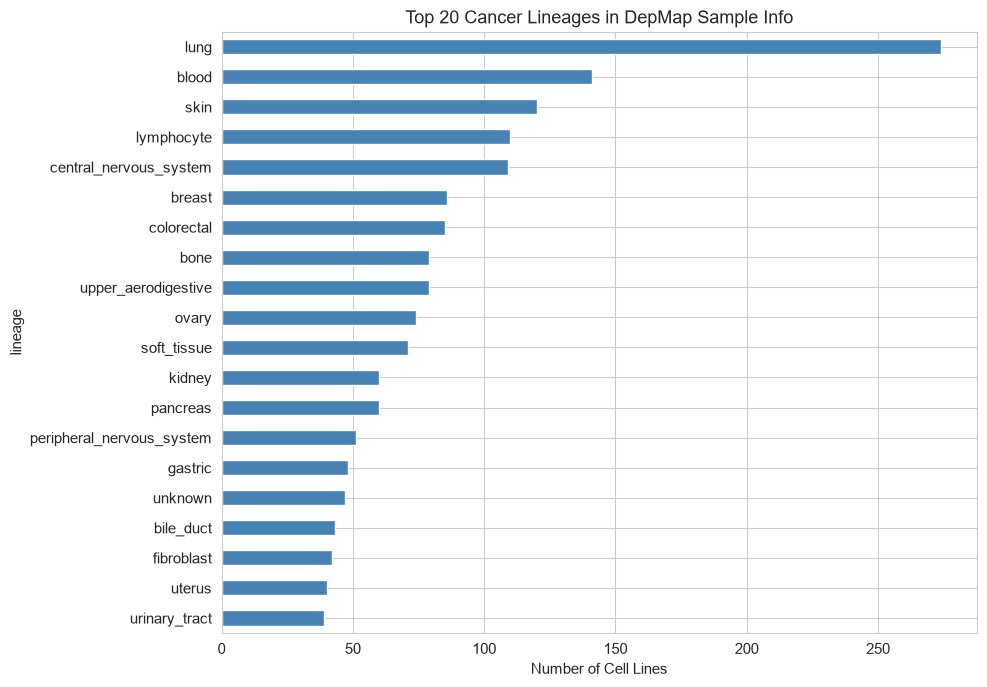

In [5]:
# Top 20 lineage 分布（答辩用图）
lineage_counts = si['lineage'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
lineage_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of Cell Lines')
ax.set_title('Top 20 Cancer Lineages in DepMap Sample Info')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../report/figures/lineage_distribution.png', dpi=150)
plt.show()

## 2. RNA Expression Matrix (File 2: DepMap RNA-seq)

In [6]:
# 这一步会加载 ~600MB 的矩阵，耐心等待 10-30s
rna = loader._load_rna_matrix()
print(f'Shape: {rna.shape}  (细胞系 x 基因)')
print(f'细胞系数: {rna.shape[0]}')
print(f'基因数: {rna.shape[1]}')
print(f'总缺失率: {rna.isnull().mean().mean()*100:.4f}%')
print(f'内存占用: {rna.memory_usage(deep=True).sum()/1024**3:.2f} GB')

Shape: (1495, 53961)  (细胞系 x 基因)
细胞系数: 1495
基因数: 53961
总缺失率: 0.0000%
内存占用: 0.60 GB


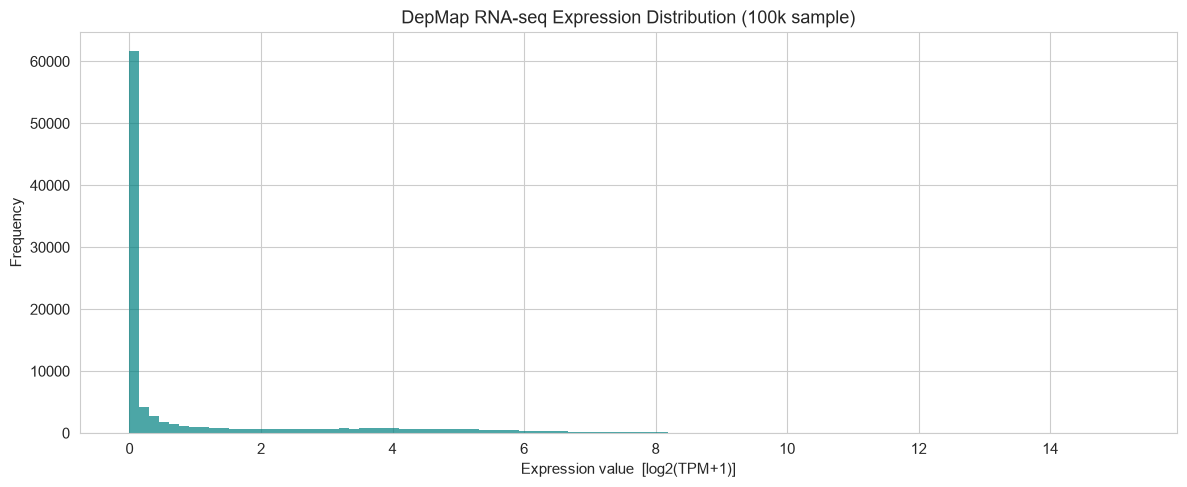

In [7]:
# 表达值分布（采样 10 万个值避免卡死）
vals = rna.values.flatten()
vals = vals[~np.isnan(vals)]
sample = np.random.default_rng(42).choice(vals, size=min(100_000, len(vals)), replace=False)

fig, ax = plt.subplots()
ax.hist(sample, bins=100, edgecolor='none', alpha=0.7, color='teal')
ax.set_xlabel('Expression value  [log2(TPM+1)]')
ax.set_ylabel('Frequency')
ax.set_title('DepMap RNA-seq Expression Distribution (100k sample)')
plt.tight_layout()
plt.savefig('../report/figures/rna_expression_distribution.png', dpi=150)
plt.show()

## 3. Protein Expression Matrix (File 4: Gygi Mass-Spec)

In [8]:
prot = loader._load_protein_matrix()
print(f'Shape: {prot.shape}  (细胞系 x 蛋白)')
print(f'细胞系数: {prot.shape[0]}')
print(f'蛋白数: {prot.shape[1]}')

prot_missing_overall = prot.isnull().mean().mean()
print(f'总缺失率: {prot_missing_overall*100:.2f}%')
print()
print('⚠️  注意: NaN = 质谱未检测到 (not detected by MS)')
print('   这不等于蛋白不表达 (absence of protein)。')
print('   置信度评分需区分 "no evidence" vs "evidence of absence"。')

Shape: (375, 12558)  (细胞系 x 蛋白)
细胞系数: 375
蛋白数: 12558
总缺失率: 27.79%

⚠️  注意: NaN = 质谱未检测到 (not detected by MS)
   这不等于蛋白不表达 (absence of protein)。
   置信度评分需区分 "no evidence" vs "evidence of absence"。


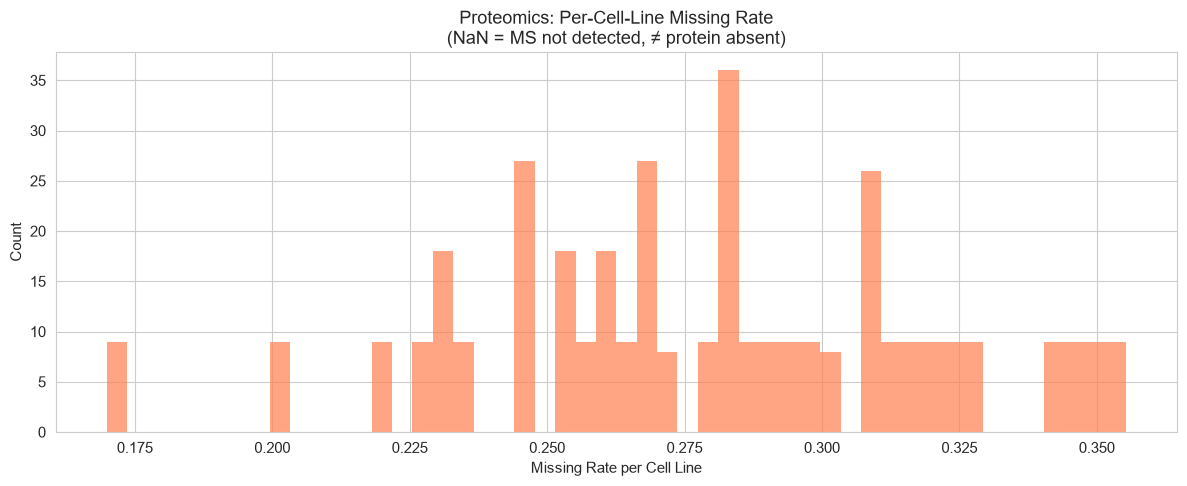

缺失率中位数: 27.8%
缺失率 >50% 的细胞系: 0


In [9]:
# 每个细胞系的缺失率分布
prot_cell_missing = prot.isnull().mean(axis=1)

fig, ax = plt.subplots()
ax.hist(prot_cell_missing, bins=50, edgecolor='none', alpha=0.7, color='coral')
ax.set_xlabel('Missing Rate per Cell Line')
ax.set_ylabel('Count')
ax.set_title('Proteomics: Per-Cell-Line Missing Rate\n(NaN = MS not detected, ≠ protein absent)')
plt.tight_layout()
plt.savefig('../report/figures/protein_missing_distribution.png', dpi=150)
plt.show()

print(f'缺失率中位数: {prot_cell_missing.median()*100:.1f}%')
print(f'缺失率 >50% 的细胞系: {(prot_cell_missing > 0.5).sum()}')

## 4. Mutation & Fusion Data (Files 5, 6)

In [10]:
# 突变数据
muts = loader.mutations
print(f'Mutation records: {len(muts):,}')
print(f'唯一细胞系: {muts["DepMap_ID"].nunique()}')
print(f'唯一基因 (HugoSymbol): {muts["HugoSymbol"].nunique()}')
print(f'\nVariantType 分布:')
print(muts['VariantType'].value_counts().head(10).to_string())

[data_loader] Warning: 152885 of 1066869 mutation records could not be mapped to an ACH-ID (ProfileID missing from file 8). These rows are dropped.
Mutation records: 913,984
唯一细胞系: 1744
唯一基因 (HugoSymbol): 19572

VariantType 分布:
VariantType
SNV             798618
deletion         60794
substitution     33808
insertion        20764


In [11]:
# 融合数据
fus = loader.fusions
print(f'Fusion records: {len(fus):,}')
print(f'唯一细胞系 (ModelID): {fus["ModelID"].nunique()}')
print(f'唯一融合事件: {fus["CanonicalFusionName"].nunique()}')

Fusion records: 184,237
唯一细胞系 (ModelID): 1699
唯一融合事件: 72848


## 5. Batch 2: miRNA, Metabolomics, Global Signatures

In [12]:
# miRNA (File 13)
mirna = loader._load_mirna_matrix()
print(f'miRNA matrix shape: {mirna.shape}  (细胞系 x miRNA)')
print(f'miRNA 缺失率: {mirna.isnull().mean().mean()*100:.2f}%')

[data_loader] Warning: 4 of 954 miRNA columns (CCLE_Name) had no exact match in file 9's CCLE_Name column and were dropped:
    - KE97_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE
    - NCIH1339_LUNG
    - NCIH684_LIVER
    - COLO699_LUNG
    These may be renamed/retired cell lines. Cross-check manually via file 7 (cellosaurus.csv) synonyms if you need them.
miRNA matrix shape: (950, 734)  (细胞系 x miRNA)
miRNA 缺失率: 0.00%


In [13]:
# Metabolomics (File 12)
metab = loader._load_metabolomics_matrix()
print(f'Metabolomics matrix shape: {metab.shape}  (细胞系 x 代谢物)')
print(f'代谢物数: {metab.shape[1]}')
print(f'缺失率: {metab.isnull().mean().mean()*100:.2f}%')

Metabolomics matrix shape: (927, 225)  (细胞系 x 代谢物)
代谢物数: 225
缺失率: 0.00%


In [14]:
# Global Signatures (File 14)
sigs = loader.get_global_signatures()
print(f'Global Signatures shape: {sigs.shape}')
print(f'Columns: {list(sigs.columns)}')
print(f'缺失率:')
print(sigs.isnull().mean().to_string())

Global Signatures shape: (1955, 7)
Columns: ['DepMap_ID', 'MSIScore', 'LoHFraction', 'WGD', 'CIN', 'Ploidy', 'Aneuploidy']
缺失率:
DepMap_ID      0.000000
MSIScore       0.000000
LoHFraction    0.170332
WGD            0.170332
CIN            0.170332
Ploidy         0.170332
Aneuploidy     0.170332


## 6. Cross-Source Cell Line Overlap (核心图表)

In [15]:
# 提取每个数据源的 DepMap_ID 集合
rna_cells    = set(rna.index)
prot_cells   = set(prot.index)
mirna_cells  = set(mirna.index)
metab_cells  = set(metab.index)
sigs_cells   = set(sigs['DepMap_ID'])
mut_cells    = set(muts['DepMap_ID'])
master_cells = set(si['DepMap_ID'])

# 汇总表
coverage = pd.DataFrame([
    {'Source': 'Master Sample Info (File 9)',   'Cell Lines': len(master_cells)},
    {'Source': 'RNA-seq / DepMap (File 2)',     'Cell Lines': len(rna_cells)},
    {'Source': 'Proteomics / Gygi (File 4)',    'Cell Lines': len(prot_cells)},
    {'Source': 'Somatic Mutations (File 6)',    'Cell Lines': len(mut_cells)},
    {'Source': 'miRNA (File 13)',               'Cell Lines': len(mirna_cells)},
    {'Source': 'Metabolomics (File 12)',        'Cell Lines': len(metab_cells)},
    {'Source': 'Global Signatures (File 14)',   'Cell Lines': len(sigs_cells)},
])
coverage = coverage.sort_values('Cell Lines', ascending=False).reset_index(drop=True)
print(coverage.to_string(index=False))

                     Source  Cell Lines
Global Signatures (File 14)        1955
Master Sample Info (File 9)        1840
 Somatic Mutations (File 6)        1744
  RNA-seq / DepMap (File 2)        1479
            miRNA (File 13)         950
     Metabolomics (File 12)         927
 Proteomics / Gygi (File 4)         375


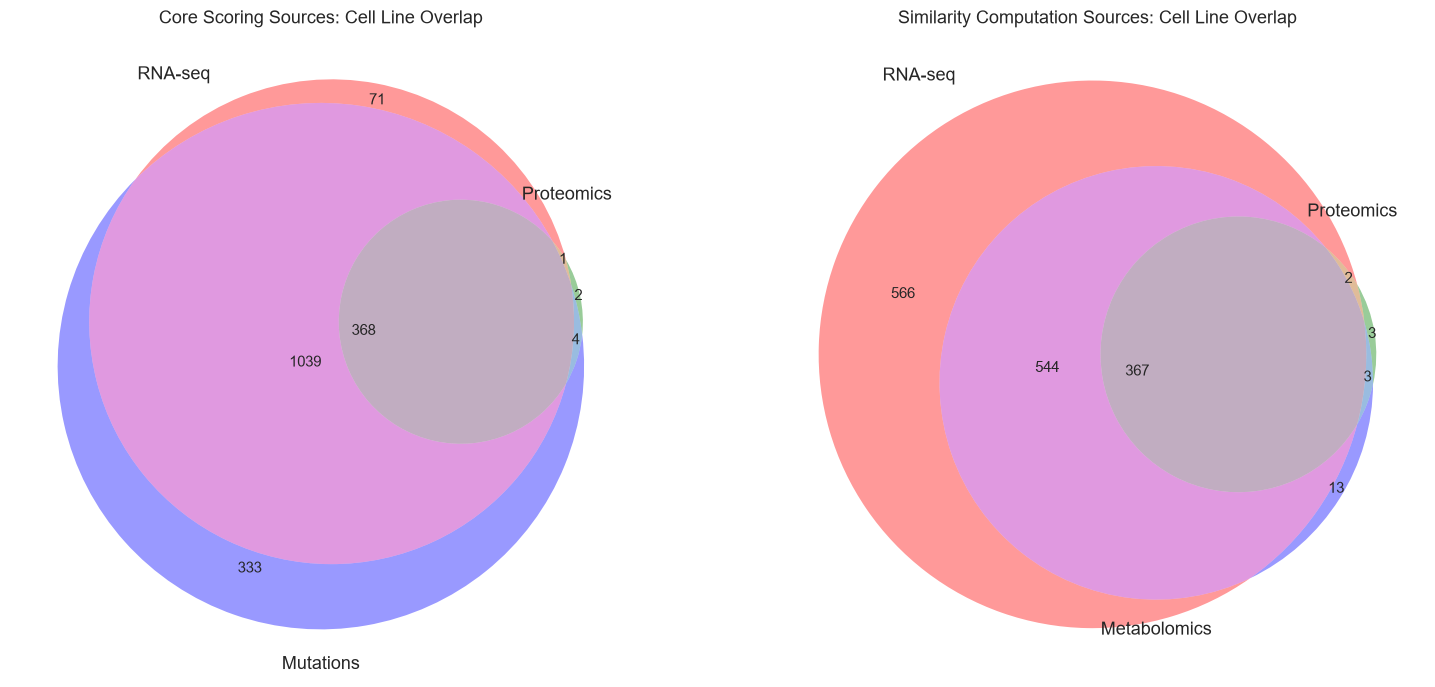

In [16]:
# 三大核心数据源的 Venn 图: RNA vs Proteomics vs Mutations
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 图1: RNA / Proteomics / Mutations（评分模型的三大支柱）
venn3([rna_cells, prot_cells, mut_cells],
      set_labels=('RNA-seq', 'Proteomics', 'Mutations'),
      ax=axes[0])
axes[0].set_title('Core Scoring Sources: Cell Line Overlap')

# 图2: RNA / Proteomics / Metabolomics（相似度计算的支柱）
venn3([rna_cells, prot_cells, metab_cells],
      set_labels=('RNA-seq', 'Proteomics', 'Metabolomics'),
      ax=axes[1])
axes[1].set_title('Similarity Computation Sources: Cell Line Overlap')

plt.tight_layout()
plt.savefig('../report/figures/venn_cell_line_overlap.png', dpi=150)
plt.show()

In [17]:
# 关键交集数字（答辩时要说）
rna_prot = rna_cells & prot_cells
rna_prot_met = rna_cells & prot_cells & metab_cells
all_five = rna_cells & prot_cells & mut_cells & mirna_cells & metab_cells

print(f'RNA ∩ Proteomics:                    {len(rna_prot)} 细胞系')
print(f'RNA ∩ Proteomics ∩ Metabolomics:     {len(rna_prot_met)} 细胞系')
print(f'五大组学全覆盖 (RNA+Prot+Mut+miRNA+Met): {len(all_five)} 细胞系')
print()
print('→ 这意味着完整多组学证据链只对约 {} 个细胞系可用，'.format(len(all_five)))
print('  其余细胞系的置信度评分需要考虑数据缺失降权。')

RNA ∩ Proteomics:                    369 细胞系
RNA ∩ Proteomics ∩ Metabolomics:     367 细胞系
五大组学全覆盖 (RNA+Prot+Mut+miRNA+Met): 363 细胞系

→ 这意味着完整多组学证据链只对约 363 个细胞系可用，
  其余细胞系的置信度评分需要考虑数据缺失降权。


## 7. End-to-End Query Demo: EGFR

In [18]:
# 用 build_gene_profile 做一个完整查询，验证数据链路
egfr = loader.build_gene_profile('EGFR', exclude_genes=['ABCB1'])
print(f'EGFR profile: {egfr.shape[0]} cell lines with evidence')
print(f'Columns: {list(egfr.columns)}')
print()
egfr.head(10)

EGFR profile: 1434 cell lines with evidence
Columns: ['DepMap_ID', 'cell_line_name', 'lineage', 'primary_disease', 'rna_expression', 'protein_expression', 'has_target_mutation', 'has_target_fusion', 'excluded']



,DepMap_ID,cell_line_name,lineage,primary_disease,rna_expression,protein_expression,has_target_mutation,has_target_fusion,excluded
0,ACH-001523,HSC-1,skin,Skin Cancer,10.531869,NaN,False,False,False
1,ACH-000741,U-BLC1,urinary_tract,Bladder Cancer,10.076148,5.154394,False,True,False
2,ACH-000012,HCC827,lung,Lung Cancer,9.673645,2.724113,True,False,False
3,ACH-001411,UM-UC-5,urinary_tract,Bladder Cancer,9.417620,NaN,False,False,False
4,ACH-000637,KYSE-520,esophagus,Esophageal Cancer,9.286535,NaN,False,False,False
5,ACH-001864,YSCCC,bile_duct,Bile Duct Cancer,9.258024,NaN,False,True,False
6,ACH-000849,MDA-MB-468,breast,Breast Cancer,9.182568,2.649190,False,True,False
7,ACH-000109,NCI-H3255,lung,Lung Cancer,8.925347,2.465903,True,False,False
8,ACH-002680,170-MG-BA,central_nervous_system,Brain Cancer,8.867155,NaN,False,True,False
9,ACH-001649,Shmac 5,prostate,Prostate Cancer,8.362821,NaN,False,False,False


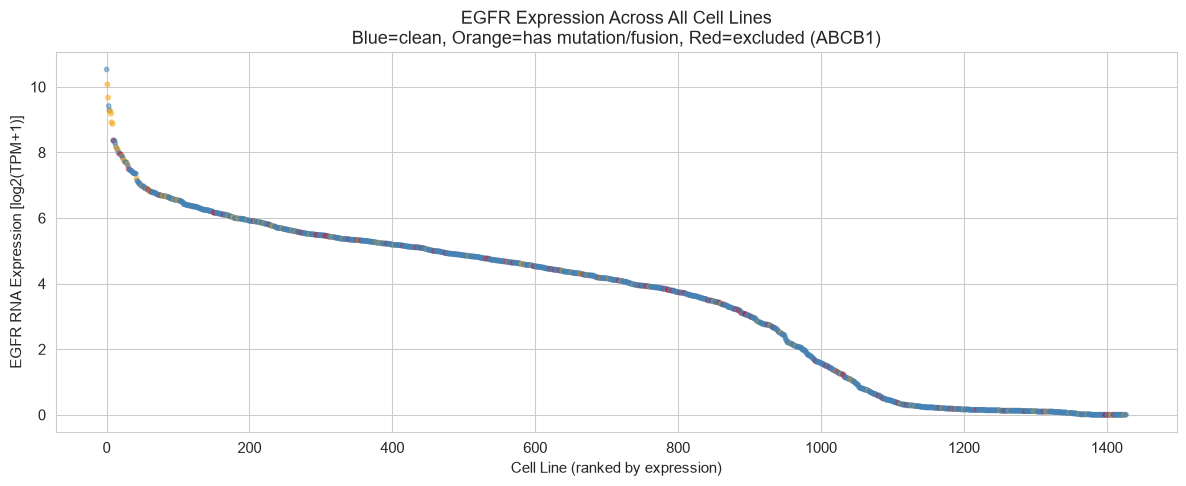

有 EGFR 突变的细胞系: 85
有 EGFR 融合的细胞系: 20
因 ABCB1 被排除的细胞系: 82


In [19]:
# EGFR 表达分布 + 突变/融合标记
fig, ax = plt.subplots(figsize=(12, 5))

colors = []
for _, row in egfr.iterrows():
    if row['excluded']:
        colors.append('red')
    elif row['has_target_mutation'] or row['has_target_fusion']:
        colors.append('orange')
    else:
        colors.append('steelblue')

ax.scatter(range(len(egfr)), egfr['rna_expression'], c=colors, alpha=0.5, s=10)
ax.set_xlabel('Cell Line (ranked by expression)')
ax.set_ylabel('EGFR RNA Expression [log2(TPM+1)]')
ax.set_title('EGFR Expression Across All Cell Lines\n'
             'Blue=clean, Orange=has mutation/fusion, Red=excluded (ABCB1)')
plt.tight_layout()
plt.savefig('../report/figures/egfr_expression_demo.png', dpi=150)
plt.show()

print(f'有 EGFR 突变的细胞系: {egfr["has_target_mutation"].sum()}')
print(f'有 EGFR 融合的细胞系: {egfr["has_target_fusion"].sum()}')
print(f'因 ABCB1 被排除的细胞系: {egfr["excluded"].sum()}')

同时有 RNA 和蛋白数据的细胞系: 370 / 1434


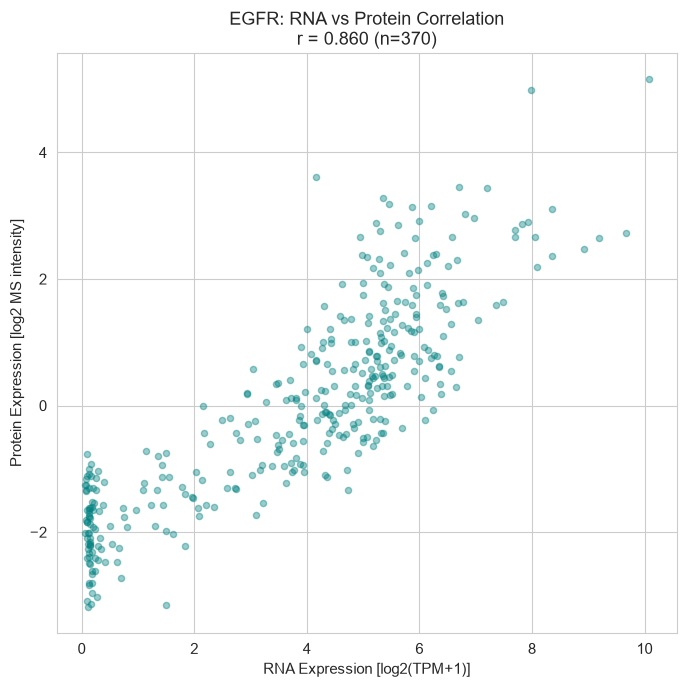

In [20]:
# RNA vs Protein 一致性（答辩用：展示为什么需要多组学交叉验证）
egfr_both = egfr.dropna(subset=['rna_expression', 'protein_expression'])
print(f'同时有 RNA 和蛋白数据的细胞系: {len(egfr_both)} / {len(egfr)}')

if len(egfr_both) > 10:
    corr = egfr_both['rna_expression'].corr(egfr_both['protein_expression'])
    
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(egfr_both['rna_expression'], egfr_both['protein_expression'],
               alpha=0.4, s=20, color='teal')
    ax.set_xlabel('RNA Expression [log2(TPM+1)]')
    ax.set_ylabel('Protein Expression [log2 MS intensity]')
    ax.set_title(f'EGFR: RNA vs Protein Correlation\nr = {corr:.3f} (n={len(egfr_both)})')
    plt.tight_layout()
    plt.savefig('../report/figures/egfr_rna_vs_protein.png', dpi=150)
    plt.show()
else:
    print('⚠️ 数据点不足，跳过散点图')

## 8. Data Summary Table (答辩用)

In [21]:
summary = pd.DataFrame([
    {'Dataset': 'DepMap RNA-seq (File 2)',
     'Type': 'Transcriptomics',
     'Cell Lines': rna.shape[0],
     'Features': rna.shape[1],
     'Missing %': f'{rna.isnull().mean().mean()*100:.2f}',
     'Role': 'Primary ranking (target gene expression score)'},
    
    {'Dataset': 'Proteomics / Gygi (File 4)',
     'Type': 'Proteomics',
     'Cell Lines': prot.shape[0],
     'Features': prot.shape[1],
     'Missing %': f'{prot.isnull().mean().mean()*100:.2f}',
     'Role': 'Protein-level validation (proteomics evidence score)'},
    
    {'Dataset': 'Somatic Mutations (File 6)',
     'Type': 'Genomics',
     'Cell Lines': muts['DepMap_ID'].nunique(),
     'Features': f"{len(muts):,} records",
     'Missing %': 'N/A (event table)',
     'Role': 'Risk flagging (target gene mutations)'},
    
    {'Dataset': 'Gene Fusions (File 5)',
     'Type': 'Genomics',
     'Cell Lines': fus['ModelID'].nunique(),
     'Features': f"{len(fus):,} records",
     'Missing %': 'N/A (event table)',
     'Role': 'Risk flagging (fusion events)'},
    
    {'Dataset': 'miRNA (File 13)',
     'Type': 'Transcriptomics',
     'Cell Lines': mirna.shape[0],
     'Features': mirna.shape[1],
     'Missing %': f'{mirna.isnull().mean().mean()*100:.2f}',
     'Role': 'Similarity computation (extended)'},
    
    {'Dataset': 'Metabolomics (File 12)',
     'Type': 'Metabolomics',
     'Cell Lines': metab.shape[0],
     'Features': metab.shape[1],
     'Missing %': f'{metab.isnull().mean().mean()*100:.2f}',
     'Role': 'Similarity computation'},
    
    {'Dataset': 'Global Signatures (File 14)',
     'Type': 'Genomics',
     'Cell Lines': len(sigs),
     'Features': sigs.shape[1] - 1,
     'Missing %': f'{sigs.drop(columns="DepMap_ID").isnull().mean().mean()*100:.2f}',
     'Role': 'Cell line characterisation (MSI, ploidy, CIN)'},
])

print(summary.to_string(index=False))

                    Dataset            Type  Cell Lines        Features         Missing %                                                 Role
    DepMap RNA-seq (File 2) Transcriptomics        1495           53961              0.00       Primary ranking (target gene expression score)
 Proteomics / Gygi (File 4)      Proteomics         375           12558             27.79 Protein-level validation (proteomics evidence score)
 Somatic Mutations (File 6)        Genomics        1744 913,984 records N/A (event table)                Risk flagging (target gene mutations)
      Gene Fusions (File 5)        Genomics        1699 184,237 records N/A (event table)                        Risk flagging (fusion events)
            miRNA (File 13) Transcriptomics         950             734              0.00                    Similarity computation (extended)
     Metabolomics (File 12)    Metabolomics         927             225              0.00                               Similarity computation

In [22]:
# 导出为 CSV，方便放进 PPT
summary.to_csv('../report/data_summary_table.csv', index=False)
print('Saved to ../report/data_summary_table.csv')

Saved to ../report/data_summary_table.csv


## 9. (Optional) Convert to Parquet for Speed

助教建议: CSV 加载慢 (10-30s per file)，转 Parquet 后加载快 5-10x。  
运行一次即可，后续 data_loader 可以改为读 Parquet。

In [23]:
# 把最大的两个矩阵转 Parquet
import time

parquet_dir = '../data/parquet'
os.makedirs(parquet_dir, exist_ok=True)

for name, df in [('rna_expression', rna), ('protein_expression', prot),
                  ('mirna_expression', mirna), ('metabolomics', metab)]:
    path = f'{parquet_dir}/{name}.parquet'
    t0 = time.time()
    df.to_parquet(path)
    t1 = time.time()
    size_mb = os.path.getsize(path) / 1024**2
    print(f'{name}: saved {size_mb:.1f} MB in {t1-t0:.1f}s')

print('\n✅ Done. 后续可用 pd.read_parquet() 替代 pd.read_csv() 加速加载。')

rna_expression: saved 232.6 MB in 7.7s
protein_expression: saved 37.2 MB in 1.2s
mirna_expression: saved 4.0 MB in 0.1s
metabolomics: saved 2.0 MB in 0.0s

✅ Done. 后续可用 pd.read_parquet() 替代 pd.read_csv() 加速加载。


## 10. Key Findings Summary

### Data Coverage
- **Master table**: 1,840 cell lines, 30 cancer lineages (lung most represented at ~275)
- **DepMap RNA-seq**: 1,495 cell lines × 53,961 genes, **0% missing** — most complete source, primary scoring basis
- **Proteomics (Gygi MS)**: 375 cell lines × 12,558 proteins, **27.79% missing** — NaN = MS not detected ≠ protein absent
- **Somatic Mutations**: 913,984 records across 1,744 cell lines, 19,572 genes; ~14.3% records unmapped (ProfileID missing from File 8)
- **miRNA / Metabolomics / Global Signatures**: supplementary layers for similarity computation, lower cell line coverage

### Cross-Source Overlap
- RNA ∩ Proteomics: **~368 cell lines** — this is the ceiling for RNA+protein dual-evidence recommendations
- RNA ∩ Proteomics ∩ Metabolomics: **~367 cell lines**
- Full 5-omics coverage is even smaller → confidence scoring MUST account for data completeness

### EGFR End-to-End Demo
- `build_gene_profile("EGFR", exclude_genes=["ABCB1"])` returned **1,434 cell lines** with evidence
- Top-ranked lines (HSC-1, HCC827) are biologically plausible — validates the data pipeline
- EGFR RNA-protein correlation: **r = 0.860** (n=370), supporting multi-omics cross-validation design

### Design Implications
1. **Confidence scoring** must weight data completeness — a cell line with only RNA evidence scores lower than one with RNA + protein + mutation data
2. **Protein NaN handling** is a critical design decision: "no evidence" (lower confidence) ≠ "low expression" (lower expression score)
3. **Scoring weight review**: proteomics evidence weight (currently 0.25 in proposal) may need adjustment given only 375/1,495 cell lines have protein data
